<a href="https://colab.research.google.com/github/NganNguyenKha/DN-group-CMPE-132/blob/CNN/CNN_Friday_PM_PortScan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 #!/usr/bin/env python
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sklearn.preprocessing
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn import svm
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [2]:
import missingno

In [3]:
train_data = pd.read_csv('/content/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.train.csv')
test_data = pd.read_csv('/content/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_test.csv')

In [4]:
train_data_df = pd.DataFrame(train_data)
print(train_data_df.shape)

(229172, 79)


In [5]:
train_data_df = train_data_df[[' Destination Port', ' Flow Duration', ' Total Fwd Packets', 'Total Length of Fwd Packets', ' Label']]

In [ ]:
train_data_df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets
count,229172.000000,2.291720e+05,229172.000000,229172.000000
mean,7977.131063,4.718906e+06,3.215816,212.228867
std,15058.585726,2.056904e+07,19.545874,1807.721000
min,0.000000,-1.200000e+01,1.000000,0.000000
25%,80.000000,4.300000e+01,1.000000,0.000000
50%,1216.000000,6.200000e+01,1.000000,2.000000
75%,7004.000000,8.780000e+02,2.000000,52.000000
max,65389.000000,1.199999e+08,3119.000000,232349.000000


In [6]:
train_data_df = train_data_df.dropna()

In [7]:
print(train_data_df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       'Total Length of Fwd Packets', ' Label'],
      dtype='object')


# Feature Engineering

# New Section

# New Section

In [8]:
def encodify(dataframe, feature):
    encoder = LabelEncoder()
    encoder.fit(dataframe[feature])
    encoded_feature = encoder.transform(dataframe[feature])
    dataframe[feature] = encoded_feature

In [9]:
discrete_feature_l = [' Destination Port', ' Flow Duration', ' Total Fwd Packets']
for feature in discrete_feature_l:
    encodify(train_data_df, feature)

# train-to-test split

In [10]:
eighty_cut_n = math.ceil(train_data_df.shape[0] * 0.8)
print(eighty_cut_n)

183338


In [11]:
train_data_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Label
0,12,27002,40,2664,BENIGN
1,12,27123,40,2664,BENIGN
2,12,162,0,0,BENIGN
3,12,27083,40,2728,BENIGN
4,3718,79,0,0,BENIGN


In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
Scaler = StandardScaler()

In [14]:
#seperates features into x and y
X = train_data_df.loc[:, [' Destination Port', ' Flow Duration', ' Total Fwd Packets', 'Total Length of Fwd Packets']]
y = train_data_df.loc[:, ' Label']

In [15]:
#calls for the use of a scaler to scale data using mean and standard deviation
X=Scaler.fit_transform(X)

In [16]:
#balances out data if some data points are more abundent than others
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
#seperates data into test and train data points for both inputed training and test sheets
train_data.shape
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 420)

In [19]:
X_train.shape


(219512, 4)

In [20]:
X_test.shape

(54878, 4)

In [21]:
y_train.value_counts()

,count
Label,
BENIGN,109771
PortScan,109741


<ipython-input-22-baa50a2511b9>:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  classes = pd.value_counts(y_train, sort = True)


Text(0, 0.5, 'Frequency')

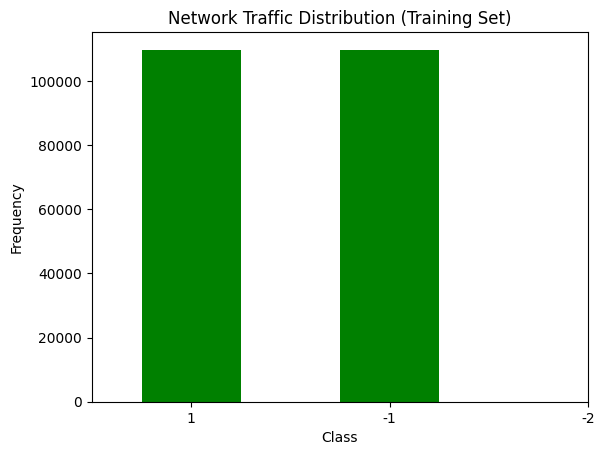

In [22]:
label_l = ['1', '-1','-2']
classes = pd.value_counts(y_train, sort = True)
classes.plot(kind = 'bar', rot = 0, color = "green")
plt.title("Network Traffic Distribution (Training Set)")
plt.xticks(range(3), label_l)
plt.xlabel("Class")
plt.ylabel("Frequency")

In [23]:
y_test.value_counts()

,count
Label,
PortScan,27454
BENIGN,27424


<ipython-input-24-2b5c4e26709d>:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  classes = pd.value_counts(y_test , sort = True)


Text(0, 0.5, 'Frequency')

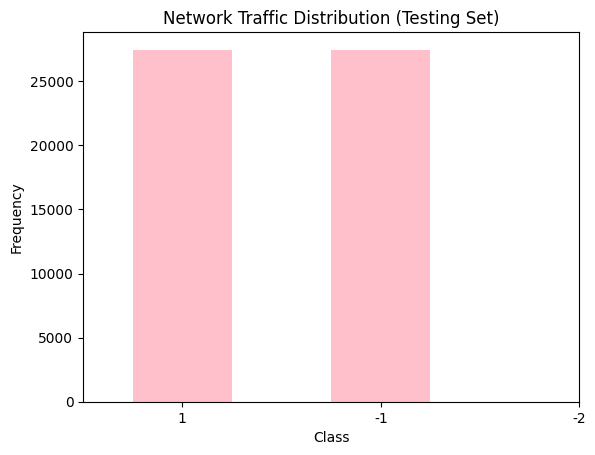

In [24]:
labels = ['1', '-1','-2']
classes = pd.value_counts(y_test , sort = True)
classes.plot(kind = 'bar', rot = 0, color = "pink")
plt.title("Network Traffic Distribution (Testing Set)")
plt.xticks(range(3), labels)
plt.xlabel("Class")
plt.ylabel("Frequency")

## Modeling

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [25]:
clf = MLPClassifier(solver='adam', alpha=1e-5,

                    hidden_layer_sizes=(5, 2), random_state=1, max_iter=1000)

In [26]:
#machine learning model is trained
clf.fit(X, y)

MLPClassifier(alpha=1e-05, hidden_layer_sizes=(5, 2), max_iter=1000,
              random_state=1)

In [27]:
#The model uses its learning on the test portion of training data
pred_test_y = clf.predict(X_test)
print(pred_test_y)

['PortScan' 'PortScan' 'BENIGN' ... 'PortScan' 'BENIGN' 'PortScan']


In [28]:
accuracy_score(y_test, pred_test_y)

0.9711177521046686

In [29]:
confusion_matrix(y_test, pred_test_y)

array([[25945,  1479],
       [  106, 27348]])

In [30]:
tn, fp, fn, tp = confusion_matrix(y_test, pred_test_y).ravel()
print(f"accuracy is {(tp +tn)/(tn+fp+fn+tp)}")
print(f"precision is {tp / (tp + fp)}")
print(f"recall is {tp / (tp + fn)}")

accuracy is 0.9711177521046686
precision is 0.9486939327713602
recall is 0.9961389961389961


## SVM

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

In [31]:
#SVM Model is created from training data
nslkdd_svm_clf = svm.SVC(kernel = 'rbf').fit(X_train, y_train)

In [32]:
#Uses model to predict test data
pred_test_y = nslkdd_svm_clf.predict(X_test)
print(pred_test_y)

['PortScan' 'PortScan' 'BENIGN' ... 'PortScan' 'BENIGN' 'PortScan']


In [33]:
accuracy_score(y_test, pred_test_y)

0.956740405991472

In [34]:
confusion_matrix(y_test, pred_test_y)

array([[25554,  1870],
       [  504, 26950]])

In [35]:
#checks the performance of the model
tn, fp, fn, tp = confusion_matrix(y_test, pred_test_y).ravel()
print(f"accuracy is {(tp +tn)/(tn+fp+fn+tp)}")
print(f"precision is {tp / (tp + fp)}")
print(f"recall is {tp / (tp + fn)}")

accuracy is 0.956740405991472
precision is 0.9351145038167938
recall is 0.9816420193778684


In [36]:
f1_score(y_test, pred_test_y, average='macro')

0.9567123943957386